# TEP 工业世界模型：从过程数据到控制规划

本教程以 Tennessee Eastman Process（TEP）为对象，构建一个动作条件的 JEPA 工业世界模型，并完成数据生成、表征学习、状态预测、反事实推演和闭环控制规划。

## TEP数据集概况

工具导入

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from tep import TEPSimulator

project_root = Path.cwd()
if not (project_root / "utils").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data.data_gen import TEPDataGenerator, load_data_config
from engine.generation import build_generation_plan, generate_dataset
from utils.visualization import (
    plot_counterfactual_comparison,
    plot_key_variable_lines,
    plot_trajectory_overview,
    plot_variable_heatmap,
    plot_vector_bar,
)

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind", font_scale=1.05)

轨迹生成

In [2]:
# 生成一条 1 小时、1 秒采样的正常闭环轨迹
seed = 42
simulator = TEPSimulator(random_seed=seed, backend="python")
result = simulator.simulate(duration_hours=1.0, record_interval=1)

# 设置列名
measurement_columns = [
    f"XMEAS({i}) {name}"
    for i, name in enumerate(simulator.get_measurement_names(), start=1)
]
action_columns = [
    f"XMV({i}) {name}"
    for i, name in enumerate(simulator.get_mv_names(), start=1)
]

# 在线可用的过程轨迹：时间、41 个测量变量和 12 个操纵变量
tep_trajectory = pd.concat(
    [
        pd.DataFrame({"time_hours": result.time}),
        pd.DataFrame(result.measurements, columns=measurement_columns),
        pd.DataFrame(result.manipulated_vars, columns=action_columns),
    ],
    axis=1,
)

# 50 维内部状态属于仿真器特权信息，单独保存
tep_states = pd.DataFrame(
    result.states,
    columns=[f"STATE({i})" for i in range(1, result.states.shape[1] + 1)],
)

print(f"轨迹采样点数: {len(tep_trajectory)}")
print(f"过程轨迹形状: {tep_trajectory.shape}")
print(f"内部状态形状: {tep_states.shape}")
print(f"是否触发停车: {result.shutdown}")
tep_trajectory.head()

轨迹采样点数: 3601
过程轨迹形状: (3601, 54)
内部状态形状: (3601, 50)
是否触发停车: False


,time_hours,XMEAS(1) A Feed (stream 1),XMEAS(2) D Feed (stream 2),XMEAS(3) E Feed (stream 3),XMEAS(4) A and C Feed (stream 4),XMEAS(5) Recycle Flow (stream 8),XMEAS(6) Reactor Feed Rate (stream 6),XMEAS(7) Reactor Pressure,XMEAS(8) Reactor Level,XMEAS(9) Reactor Temperature,...,XMV(3) A Feed Flow (stream 1),XMV(4) A and C Feed Flow (stream 4),XMV(5) Compressor Recycle Valve,XMV(6) Purge Valve (stream 9),XMV(7) Separator Pot Liquid Flow,XMV(8) Stripper Liquid Product Flow,XMV(9) Stripper Steam Valve,XMV(10) Reactor Cooling Water Flow,XMV(11) Condenser Cooling Water Flow,XMV(12) Agitator Speed
0,0.000000,0.250521,3664.038885,4509.268390,9.347742,26.902440,42.338849,2705.000000,75.000000,120.400000,...,24.643558,61.301921,22.210000,40.063747,38.100344,46.534156,47.445735,41.105813,18.113491,50.0
1,0.000278,0.250521,3664.038885,4509.268390,9.347742,26.902440,42.338849,2705.000000,75.000000,120.400000,...,26.263874,60.595414,22.210276,40.064106,38.100344,46.534156,47.445929,41.106100,18.114131,50.0
2,0.000556,0.252494,3632.402846,4504.619387,9.275586,26.680047,42.599894,2704.521753,75.050384,120.403353,...,26.263874,60.595414,22.210276,40.064106,38.100344,46.534156,47.445929,41.106100,18.114131,50.0
3,0.000833,0.253498,3673.271109,4471.339448,9.258792,27.000335,42.395277,2704.882467,75.199208,120.410779,...,26.263874,60.595414,22.210276,40.064106,38.100344,46.534156,47.445929,41.106100,18.114131,50.0
4,0.001111,0.255614,3641.960057,4436.460851,9.367677,27.140838,42.559449,2705.321432,75.428329,120.395700,...,25.978932,61.178694,22.271806,24.563023,32.351885,47.263719,47.363078,41.113061,18.077483,50.0


### XMEAS 传感器变量

XMEAS 数组维数: 2
XMEAS 形状: (3601, 41)
样本数: 3601
传感器变量数: 41


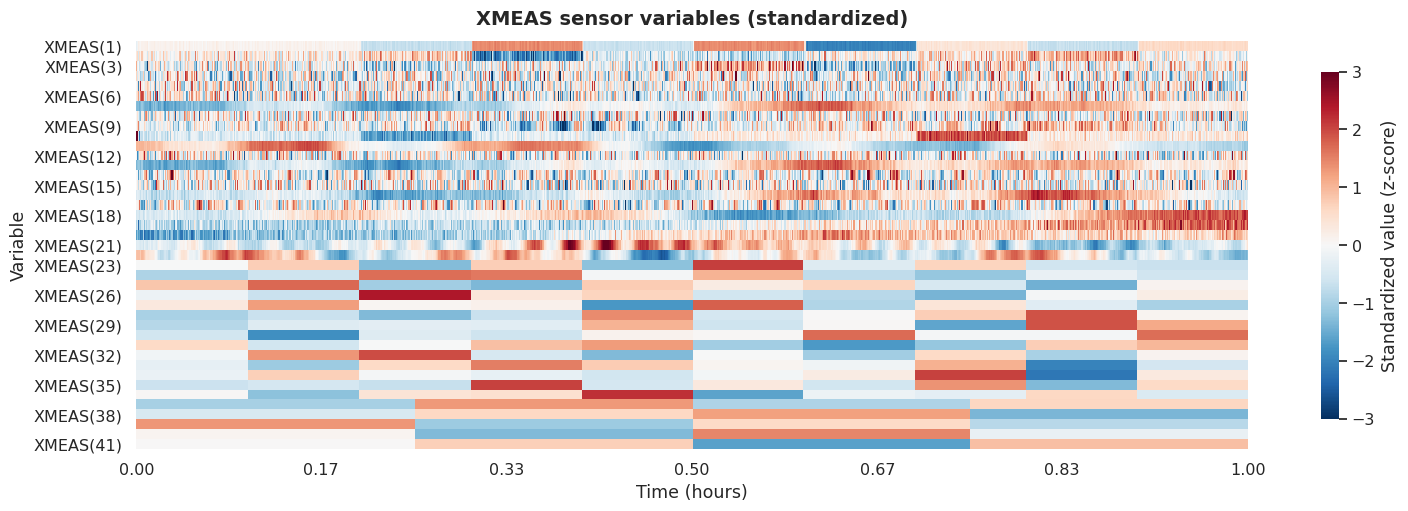

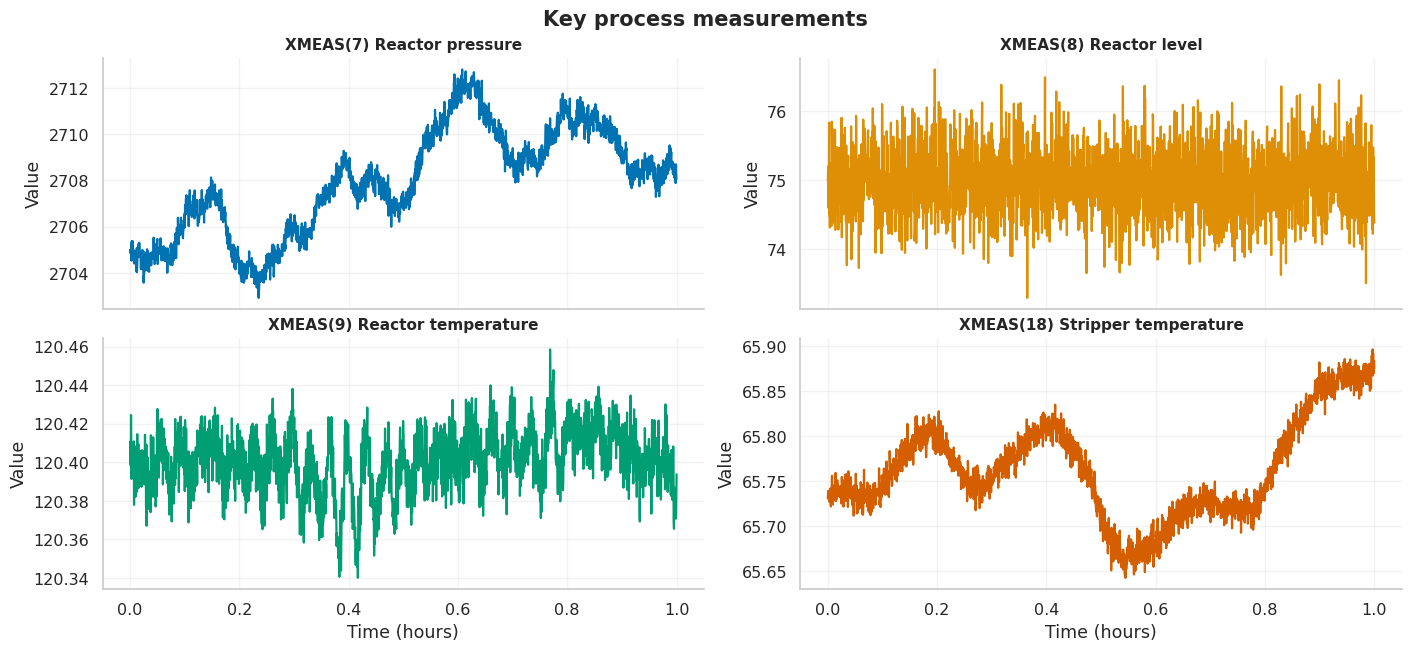

In [3]:
xmeas = pd.DataFrame(result.measurements, columns=measurement_columns)

print(f"XMEAS 数组维数: {result.measurements.ndim}")
print(f"XMEAS 形状: {result.measurements.shape}")
print(f"样本数: {result.measurements.shape[0]}")
print(f"传感器变量数: {result.measurements.shape[1]}")

plot_variable_heatmap(
    result.time,
    xmeas,
    labels=[f"XMEAS({i})" for i in range(1, xmeas.shape[1] + 1)],
    title="XMEAS sensor variables (standardized)",
)
plt.show()

plot_key_variable_lines(
    result.time,
    xmeas,
    indices=[6, 7, 8, 17],
    labels=[
        "XMEAS(7) Reactor pressure",
        "XMEAS(8) Reactor level",
        "XMEAS(9) Reactor temperature",
        "XMEAS(18) Stripper temperature",
    ],
    title="Key process measurements",
)
plt.show()

### XMV 操纵变量

XMV 数组维数: 2
XMV 形状: (3601, 12)
样本数: 3601
操纵变量数: 12


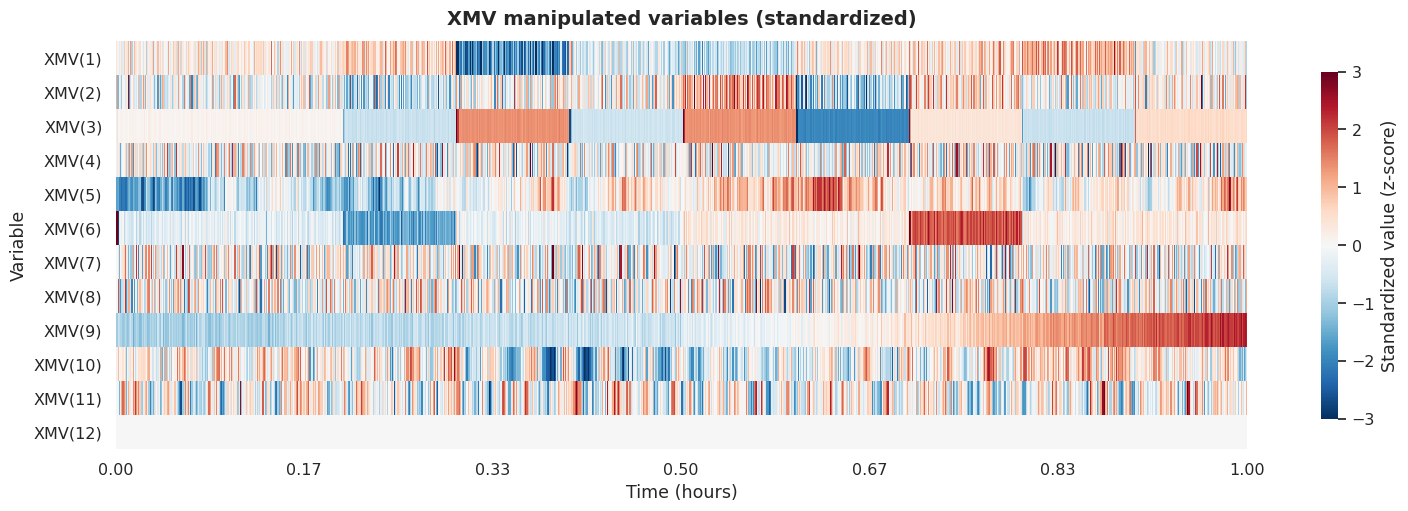

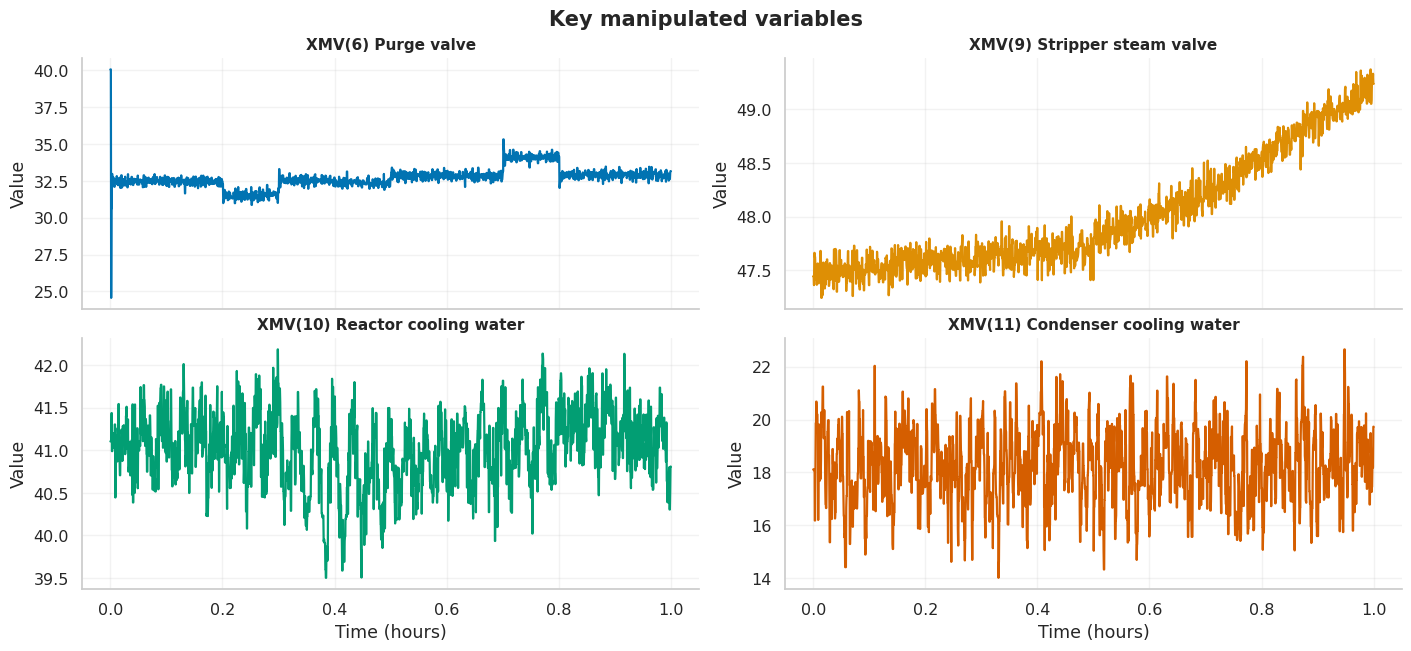

In [4]:
xmv = pd.DataFrame(result.manipulated_vars, columns=action_columns)

print(f"XMV 数组维数: {result.manipulated_vars.ndim}")
print(f"XMV 形状: {result.manipulated_vars.shape}")
print(f"样本数: {result.manipulated_vars.shape[0]}")
print(f"操纵变量数: {result.manipulated_vars.shape[1]}")

plot_variable_heatmap(
    result.time,
    xmv,
    labels=[f"XMV({i})" for i in range(1, xmv.shape[1] + 1)],
    title="XMV manipulated variables (standardized)",
)
plt.show()

plot_key_variable_lines(
    result.time,
    xmv,
    indices=[5, 8, 9, 10],
    labels=[
        "XMV(6) Purge valve",
        "XMV(9) Stripper steam valve",
        "XMV(10) Reactor cooling water",
        "XMV(11) Condenser cooling water",
    ],
    title="Key manipulated variables",
)
plt.show()

### 内部状态变量

内部状态数组维数: 2
内部状态形状: (3601, 50)
样本数: 3601
内部状态变量数: 50


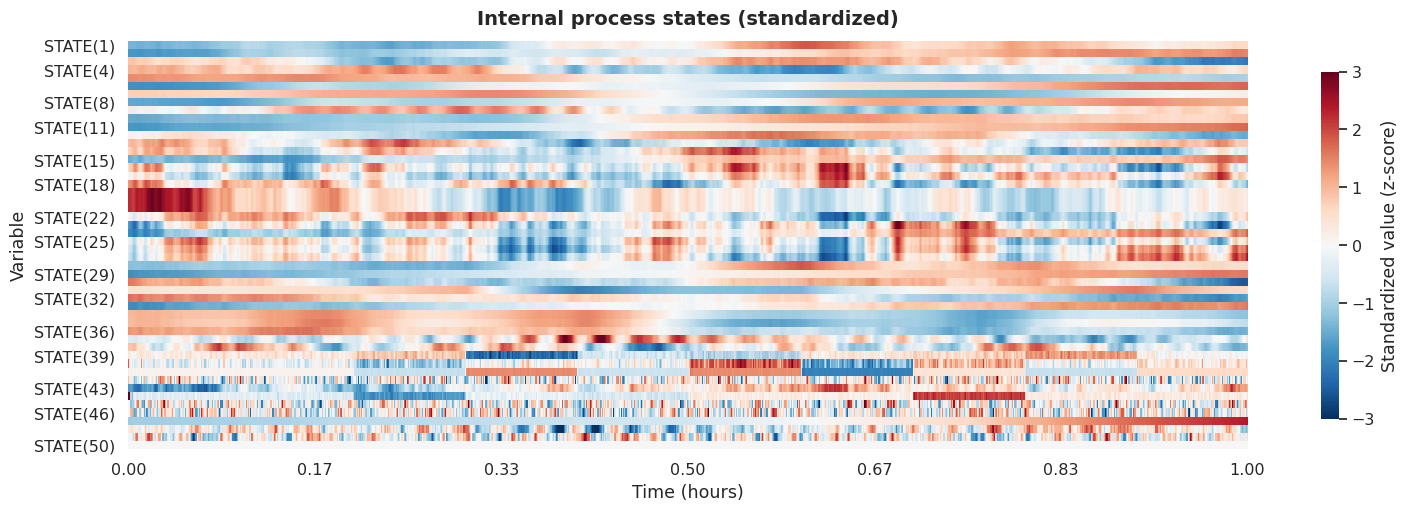

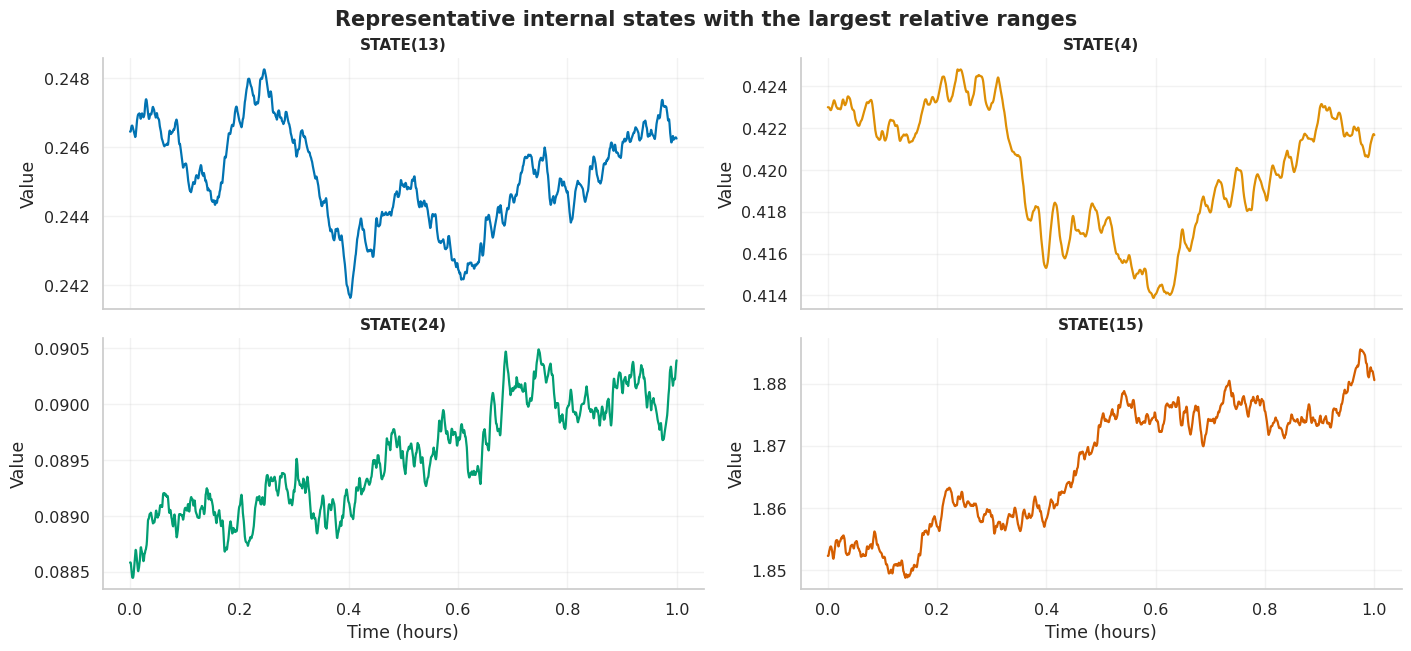

In [5]:
print(f"内部状态数组维数: {result.states.ndim}")
print(f"内部状态形状: {result.states.shape}")
print(f"样本数: {result.states.shape[0]}")
print(f"内部状态变量数: {result.states.shape[1]}")

plot_variable_heatmap(
    result.time,
    tep_states,
    labels=[f"STATE({i})" for i in range(1, tep_states.shape[1] + 1)],
    title="Internal process states (standardized)",
)
plt.show()

# 从前 38 个过程状态中选择相对变化幅度最大的 4 个，避免与末尾阀位状态重复
process_states = tep_states.iloc[:, :38]
relative_range = (process_states.max() - process_states.min()) / (process_states.mean().abs() + 1e-8)
key_state_indices = np.argsort(relative_range.to_numpy())[-4:][::-1]
key_state_labels = [process_states.columns[i] for i in key_state_indices]

plot_key_variable_lines(
    result.time,
    tep_states,
    indices=key_state_indices,
    labels=key_state_labels,
    title="Representative internal states with the largest relative ranges",
)
plt.show()

### 控制器设定值（调节器变量）

控制器类型: DecentralizedController
设定值数组维数: 1
设定值形状: (20,)
说明: 设定值是控制器参数，不包含时间维，因此不随时间变化。


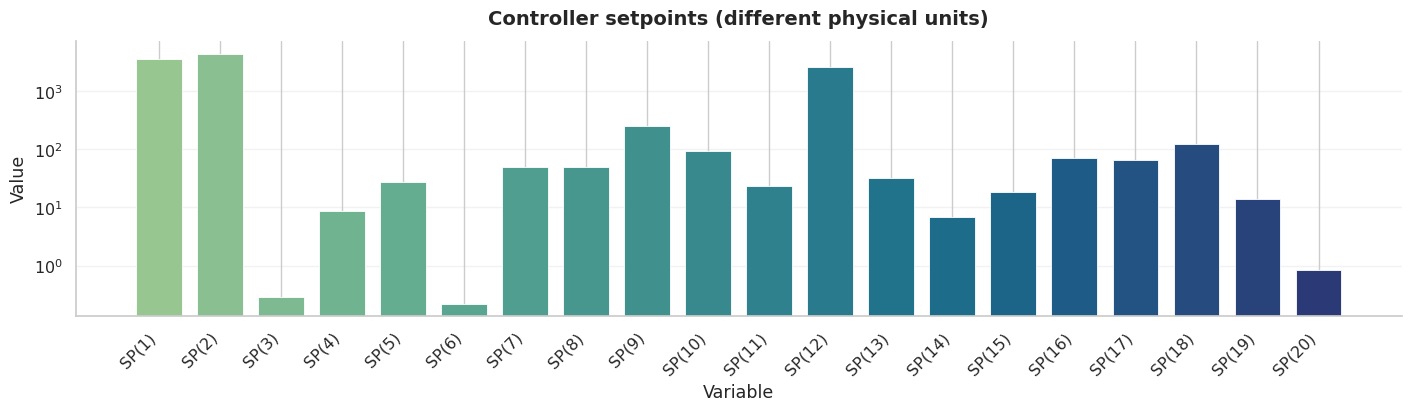

In [6]:
controller_setpoints = np.asarray(simulator.controller.setpoints)
setpoint_table = pd.DataFrame(
    {
        "controller": [f"SP({i})" for i in range(1, len(controller_setpoints) + 1)],
        "setpoint": controller_setpoints,
    }
)

print(f"控制器类型: {type(simulator.controller).__name__}")
print(f"设定值数组维数: {controller_setpoints.ndim}")
print(f"设定值形状: {controller_setpoints.shape}")
print("说明: 设定值是控制器参数，不包含时间维，因此不随时间变化。")

plot_vector_bar(
    controller_setpoints,
    labels=setpoint_table["controller"],
    title="Controller setpoints (different physical units)",
    log_scale=True,
)
plt.show()

## 世界模型的状态与动作

**观测状态**采用 `XMEAS(41) + XMV(12)`，共 53 维。XMEAS 描述过程测量，XMV 描述底层控制器实际施加的操纵量；模型使用一段历史观测推断未直接观测的过程和控制器状态。

**动作**采用可由上层规划器设定的 11 个外部 SP：

- 基础动作：SP13、SP14、SP15、SP17、SP18、SP19、SP20。
- 扩展动作：SP5、SP7、SP8、SP11，分别用于循环负荷、分离器液位、汽提塔液位和生产负荷调节。

SP1、SP2、SP3、SP4、SP6、SP9、SP10、SP16由串级控制器动态生成，属于内部控制器状态，不作为独立动作。规划器联合优化11个外部SP，逐步限制改变的SP数量与幅度，并惩罚相邻动作变化。保持原动作也作为CEM候选。

世界模型学习历史条件下的单步潜在状态转移：`历史观测/动作 + 当前SP → 下一模型步latent`；多步预测仅递归调用同一个predictor。

## 轨迹样本生成策略

| 类型 | 动作设计 | 用途 |
|---|---|---|
| 固定SP | 全程保持外部SP | 闭环基础动力学与随机波动 |
| 单动作 | 多次事件，每次仅改变一个SP | 连续单变量调节 |
| 多动作 | 多次事件，至少一次同时改变多个SP | 多变量耦合调节 |
| 干扰 | 单动作或多动作序列叠加IDV | 干扰及恢复动力学 |
| 超限 | 特殊SP序列逐步逼近并保持应激目标 | 实测软边界越限或停车 |

示例和批量数据共用生成器与配置。短保持和长保持按模型步混合采样；首次动作后安排一个短间隔，使默认30分钟评估窗口能覆盖多次动作。提前停车可能使序列未执行完整，保留真实结果并标注实际动作次数。

In [7]:
# 读取统一配置；辅助函数仅负责展示轨迹摘要和曲线。
from data.data_validation import action_change_counts
data_config = load_data_config(project_root / "configs/config.yaml")
example_plans = build_generation_plan(data_config, num_trajectories=20, counterfactual_pairs=0)
example_configs = {
    name: next(plan["config"] for plan in example_plans if plan["scenario_type"] == name)
    for name in data_config["generation"]["scenario_proportions"]
}

def show_trajectory(trajectory, config, title):
    active_idvs = np.flatnonzero(trajectory.disturbances.max(axis=0)) + 1
    counts = action_change_counts(trajectory.actions, trajectory.metadata["initial_action"])
    summary = pd.DataFrame([{
        "actual action events": int(np.count_nonzero(counts)),
        "multi-SP events": int(np.count_nonzero(counts >= 2)),
        "limit violations": str(trajectory.metadata["limit_violations"]),
        "type": trajectory.trajectory_type,
        "outcome": trajectory.outcome,
        "duration (h)": round(float(trajectory.time[-1]), 3),
        "transitions": len(trajectory.actions),
        "observation shape": str(trajectory.observations.shape),
        "action shape": str(trajectory.actions.shape),
        "changed SPs": str(list(trajectory.metadata["changed_action_sp_numbers"])),
        "active IDVs": str(active_idvs.tolist()),
        "shutdown": trajectory.shutdown,
    }])
    display(summary)
    plot_trajectory_overview(
        trajectory,
        action_sp_numbers=config["action_sp_numbers"],
        title=title,
    )
    plt.show()

### 1. 固定SP轨迹

预热至稳定工况后，所有外部SP保持不变，用于展示正常闭环运行下的基础动力学。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,0,0,{'XMEAS9': 0},fixed_sp,near_boundary,1.5,5400,"(5401, 53)","(5400, 11)",[],[],False


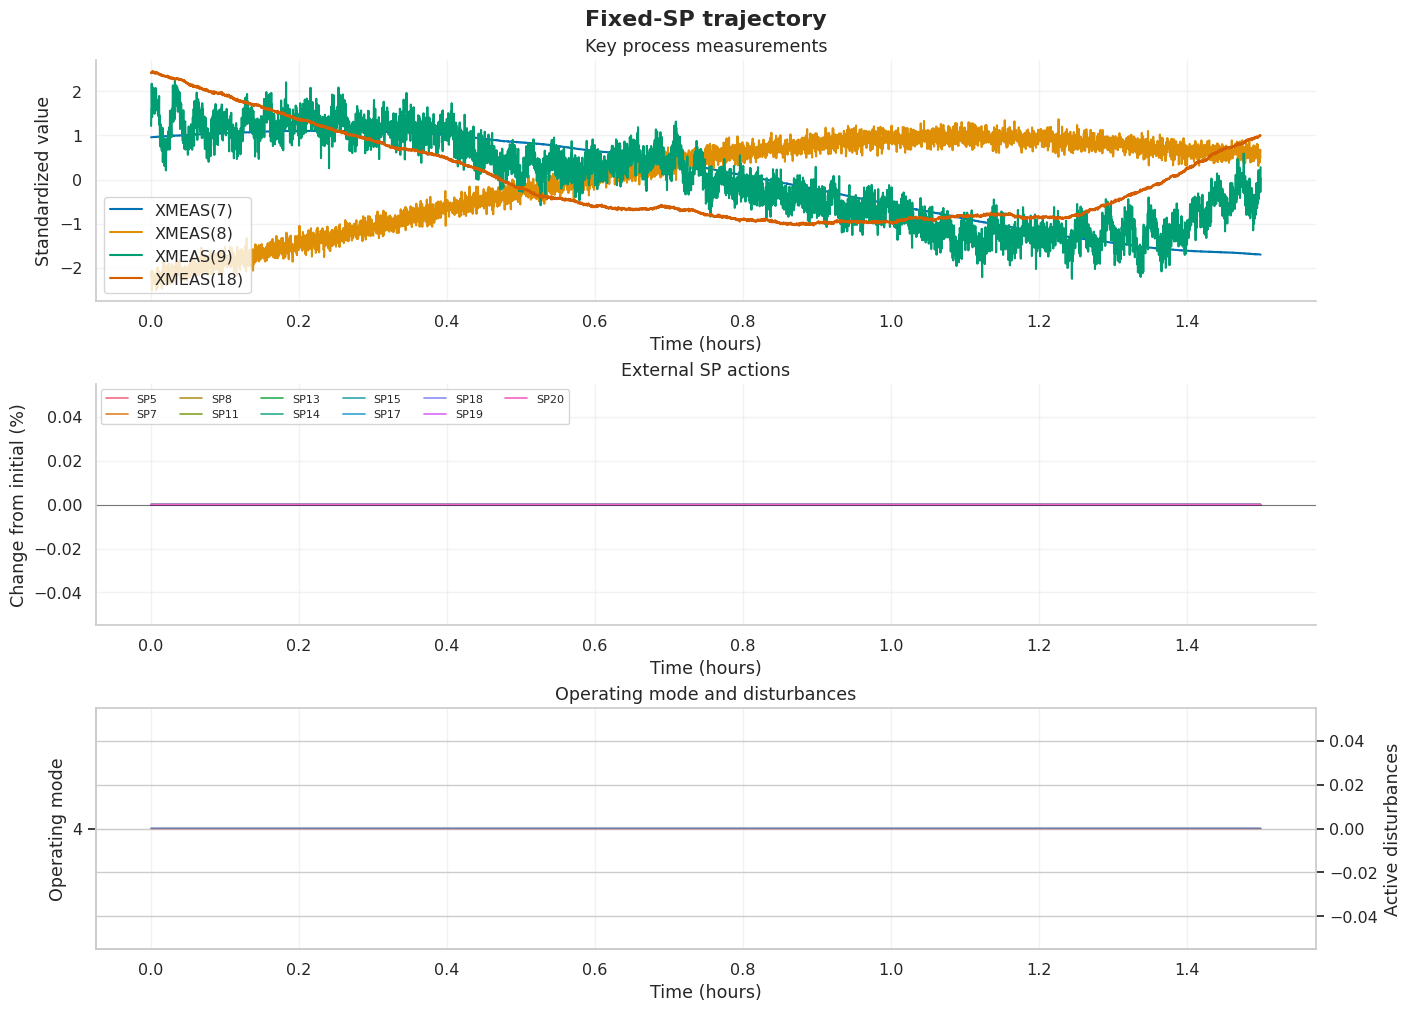

In [8]:
fixed_config = example_configs["fixed_sp"]
fixed_trajectory = TEPDataGenerator(fixed_config, initialize=False).generate_trajectory()
show_trajectory(fixed_trajectory, fixed_config, "Fixed-SP trajectory")


### 2. 单动作轨迹

整条轨迹有多次调节，每次只改变一个SP；不同事件可以调节不同SP。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,6,0,{'XMEAS9': 0},action,normal,3.083,11100,"(11101, 53)","(11100, 11)","[5, 7, 11, 13, 14, 19]",[],False


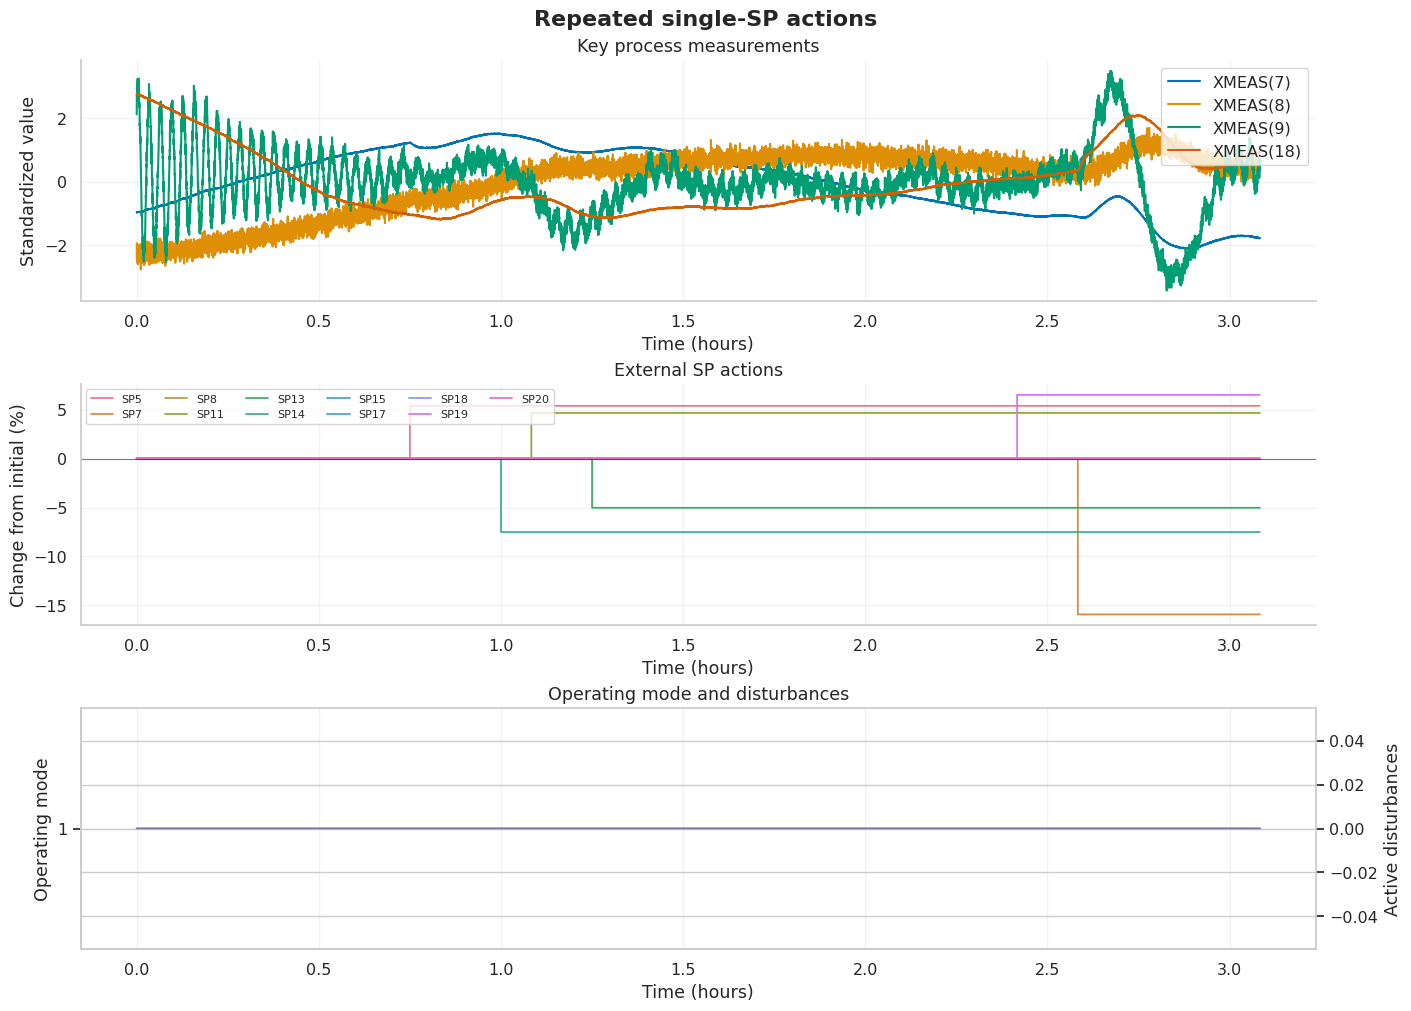

In [9]:
single_action_config = example_configs["single_action"]
single_action_trajectory = TEPDataGenerator(single_action_config, initialize=False).generate_trajectory()
show_trajectory(single_action_trajectory, single_action_config, "Repeated single-SP actions")


### 3. 多动作轨迹

整条轨迹包含多次调节，首个事件同时改变至少两个SP，后续事件可以改变一个或多个SP。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,8,7,{'XMEAS9': 0},action,normal,4.917,17700,"(17701, 53)","(17700, 11)","[5, 7, 8, 11, 13, 14, 15, 17, 18]",[],False


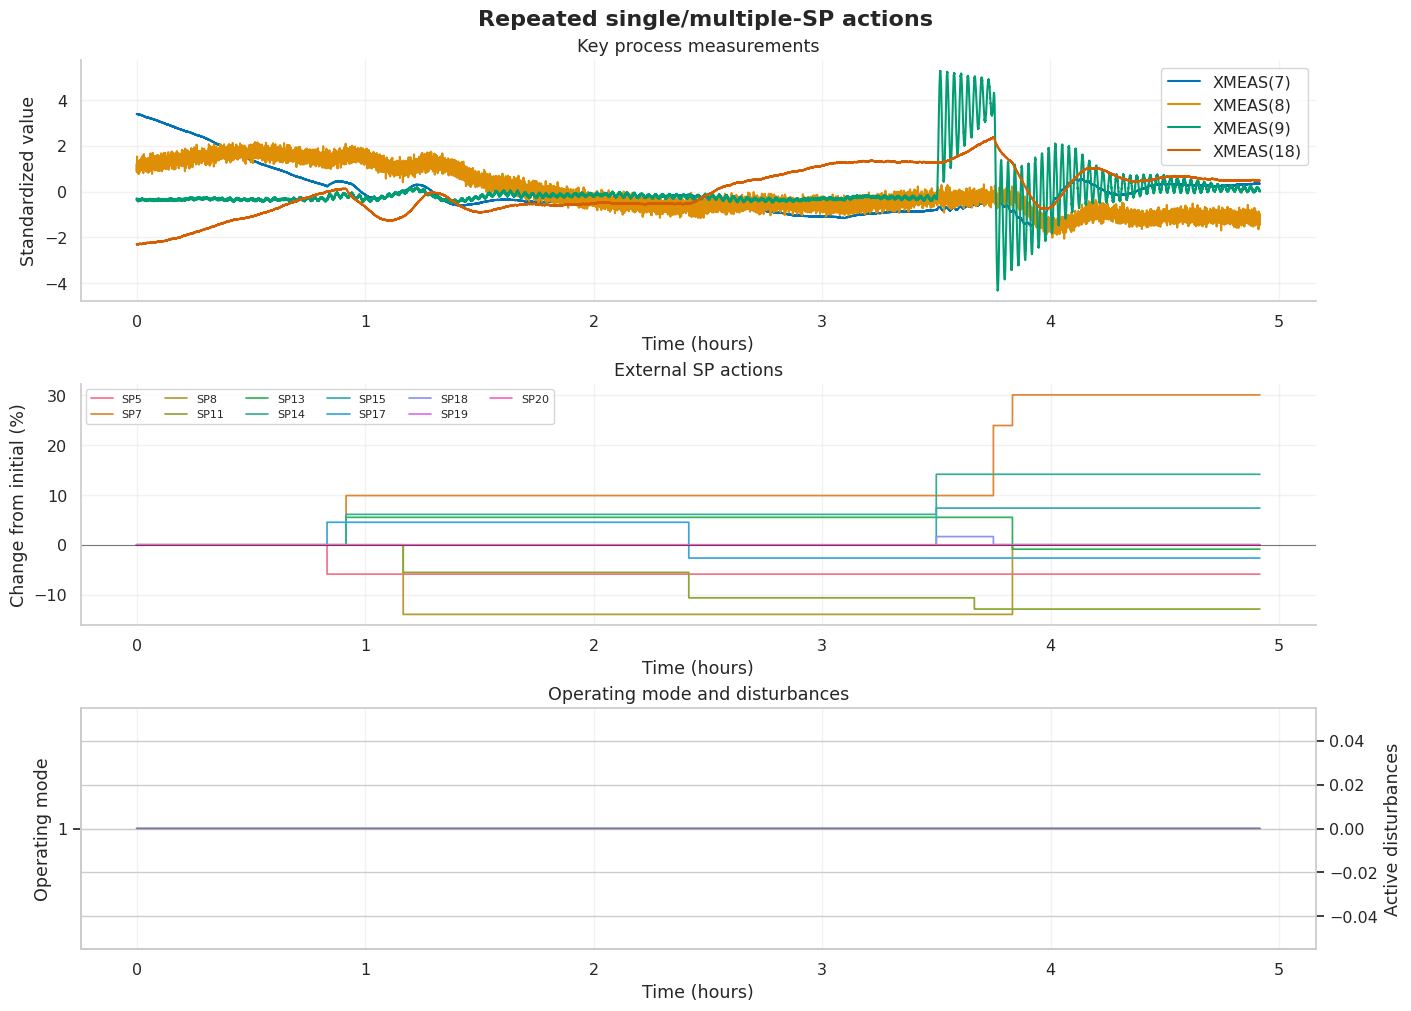

In [10]:
multi_action_config = example_configs["multi_action"]
multi_action_trajectory = TEPDataGenerator(multi_action_config, initialize=False).generate_trajectory()
show_trajectory(multi_action_trajectory, multi_action_config, "Repeated single/multiple-SP actions")


### 4. 干扰与恢复轨迹

随机选择单动作或多动作序列，再叠加IDV开启与关闭事件，保留基础动作类型。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,16,0,{'XMEAS9': 0},disturbance,normal,6.583,23700,"(23701, 53)","(23700, 11)","[5, 7, 8, 11, 14, 15, 17, 18, 19]","[3, 11]",False


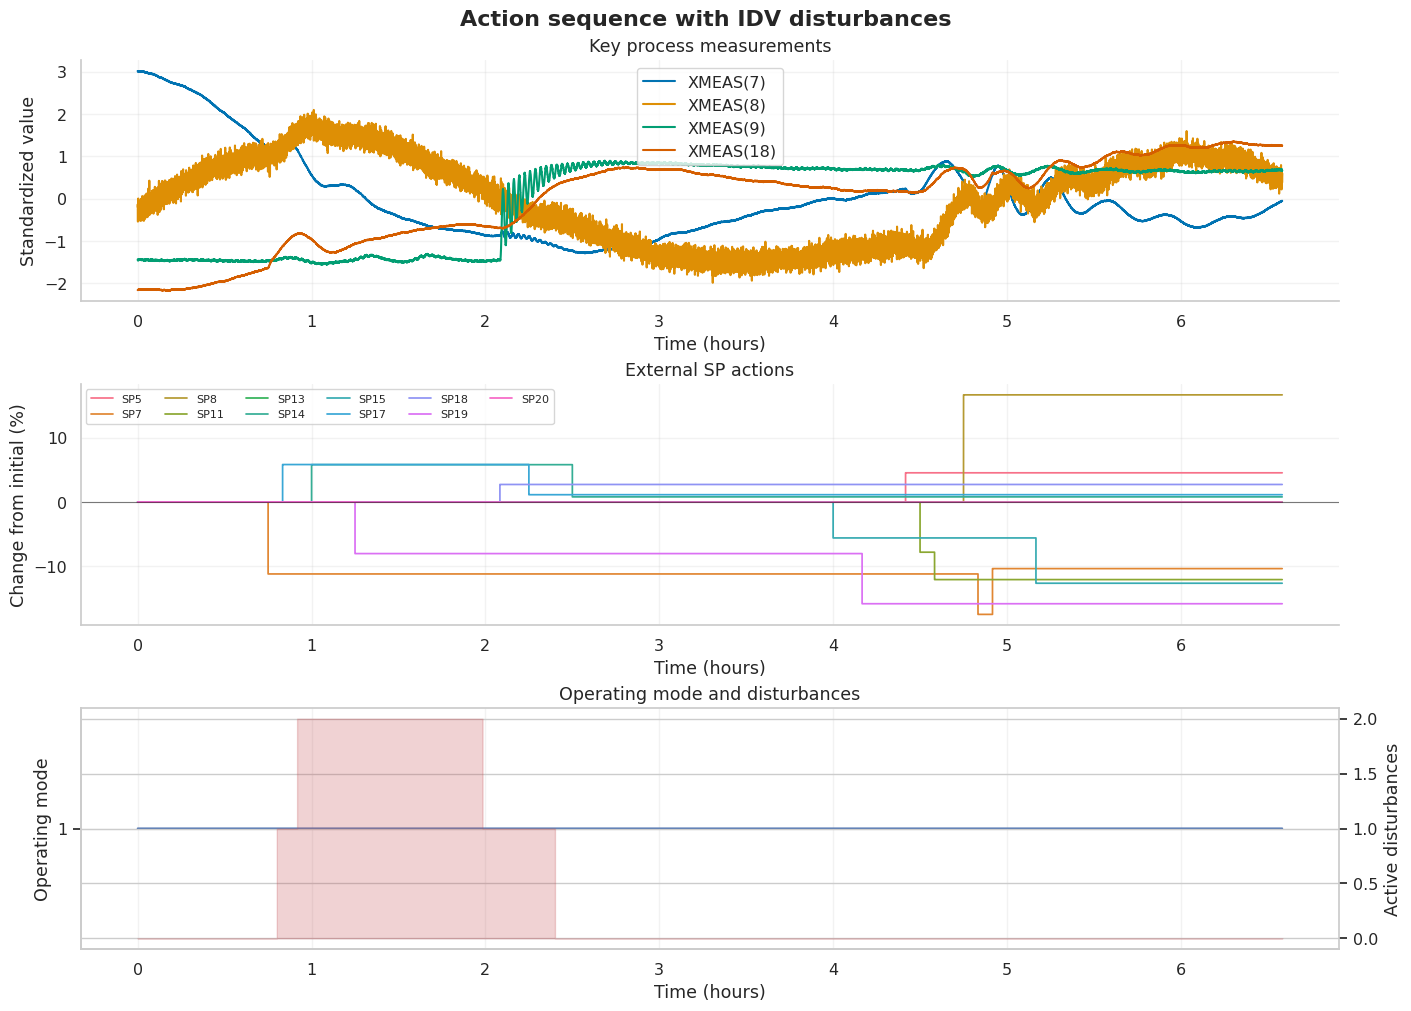

In [11]:
disturbance_config = example_configs["disturbance"]
disturbance_trajectory = TEPDataGenerator(disturbance_config, initialize=False).generate_trajectory()
show_trajectory(disturbance_trajectory, disturbance_config, "Action sequence with IDV disturbances")


### 5. 超限轨迹

按配置逐步调节并保持应激SP目标。默认SP18目标130°C，XMEAS9实验软边界为110–129°C；该边界是实验设定。是否越界依据每秒测量值和仿真器停车结果，不把应激动作意图当作已发生超限。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,2,2,{'XMEAS9': 23134},action,limit_exceeded,7.667,27600,"(27601, 53)","(27600, 11)","[5, 7, 18]",[],False


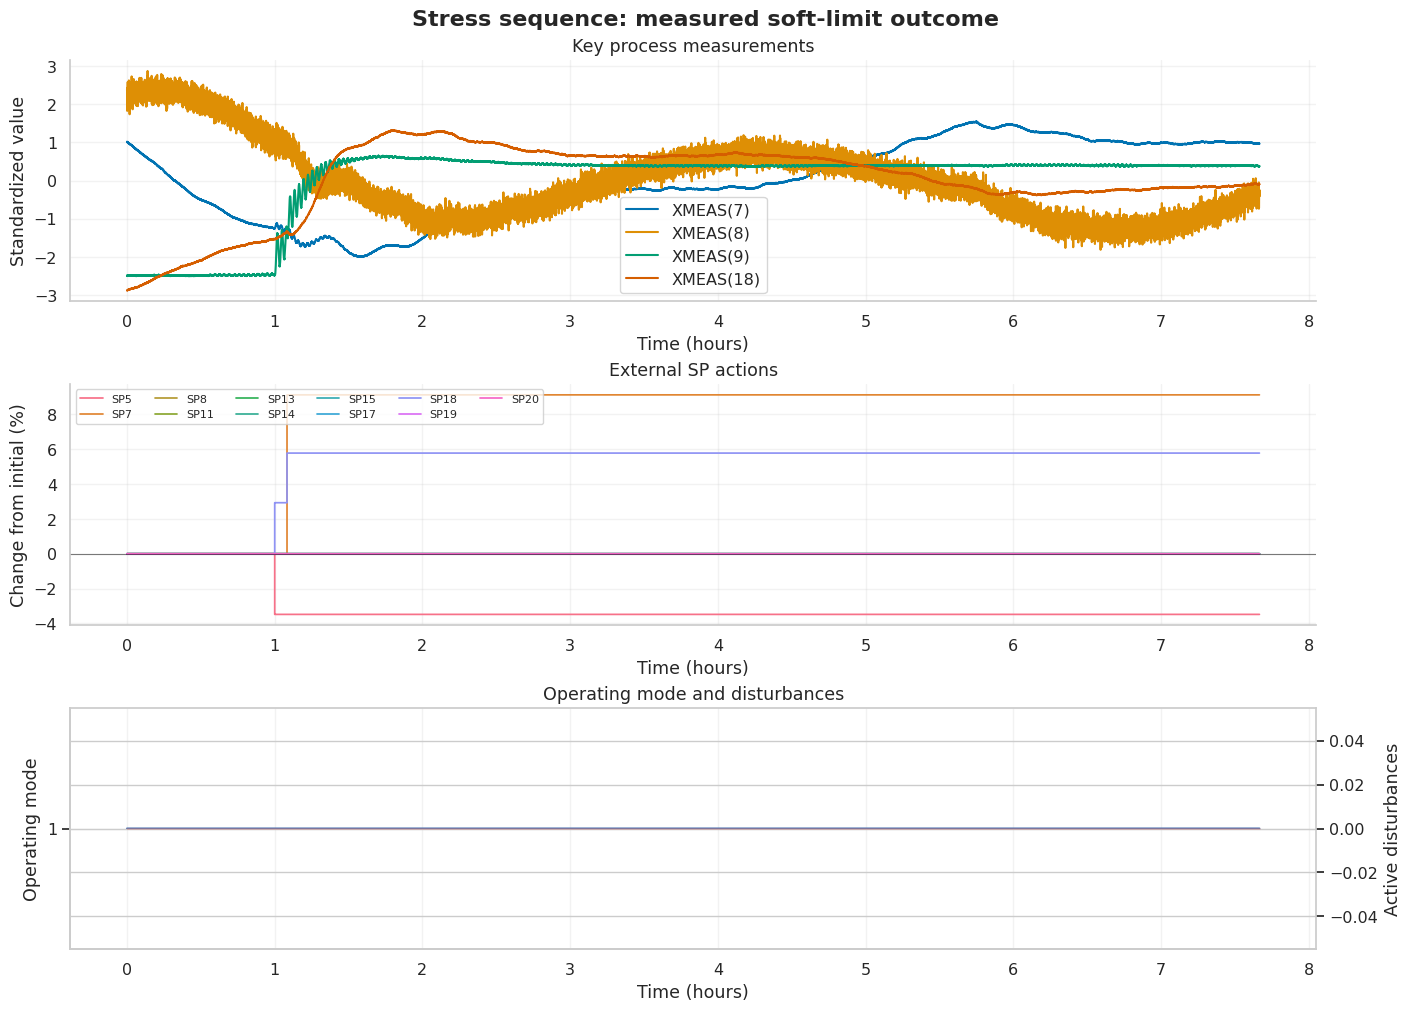

In [12]:
limit_exceeded_config = example_configs["boundary_action"]
limit_exceeded_trajectory = TEPDataGenerator(limit_exceeded_config, initialize=False).generate_trajectory()
show_trajectory(limit_exceeded_trajectory, limit_exceeded_config, "Stress sequence: measured soft-limit outcome")


### 6. 反事实轨迹对比

保持相同种子、初始工况、预热及记录时长，比较固定SP与连续单动作序列；批量生成的同源轨迹对始终划入同一数据集合。

初始观测最大差异: 0.000e+00


,variable,reference final,intervention final,counterfactual difference
0,XMEAS7 reactor pressure,2403.704,2552.181,148.477
1,XMEAS8 reactor level,65.062,67.999,2.937
2,XMEAS9 reactor temperature,122.927,122.833,-0.094
3,XMEAS38 product E,0.909,0.755,-0.153


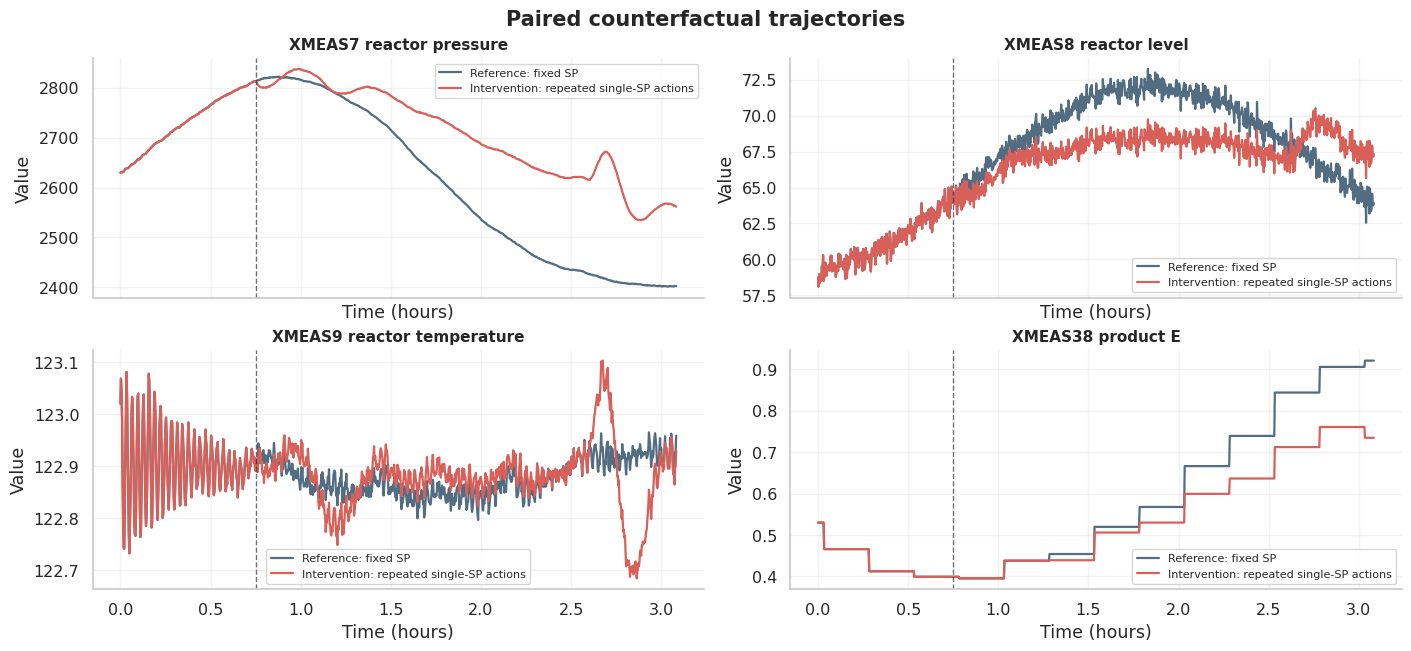

Comparison duration (h): 3.0833333333338153
Stopped at first trajectory end: False


In [13]:
# 保持相同种子、工况和预热过程，仅移除动作事件作为参考。
counterfactual_reference_config = {
    **single_action_config,
    "action_events": [],
}
counterfactual_reference = TEPDataGenerator(
    counterfactual_reference_config, initialize=False
).generate_trajectory()
counterfactual_intervention = single_action_trajectory

counterfactual_variables = {
    "XMEAS7 reactor pressure": 6,
    "XMEAS8 reactor level": 7,
    "XMEAS9 reactor temperature": 8,
    "XMEAS38 product E": 37,
}
counterfactual_comparison, counterfactual_figure, _ = (
    plot_counterfactual_comparison(
        counterfactual_reference,
        counterfactual_intervention,
        counterfactual_variables,
        reference_label="Reference: fixed SP",
        intervention_label="Intervention: repeated single-SP actions",
        intervention_time_hours=single_action_config["action_events"][0]["time_hours"],
    )
)
initial_difference = counterfactual_comparison.attrs[
    "initial_observation_max_difference"
]
print(f"初始观测最大差异: {initial_difference:.3e}")
display(counterfactual_comparison.round(3))
plt.show()

print("Comparison duration (h):", counterfactual_comparison.attrs["comparison_duration_hours"])
print("Stopped at first trajectory end:", counterfactual_comparison.attrs["truncated_at_first_end"])


### 7. 工况切换轨迹

沿用额外的工况切换样本。切换事件也与模型时间网格对齐，保留切换后的真实过程响应。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,1,0,{'XMEAS9': 0},action,normal,3.917,14100,"(14101, 53)","(14100, 11)",[18],[],False


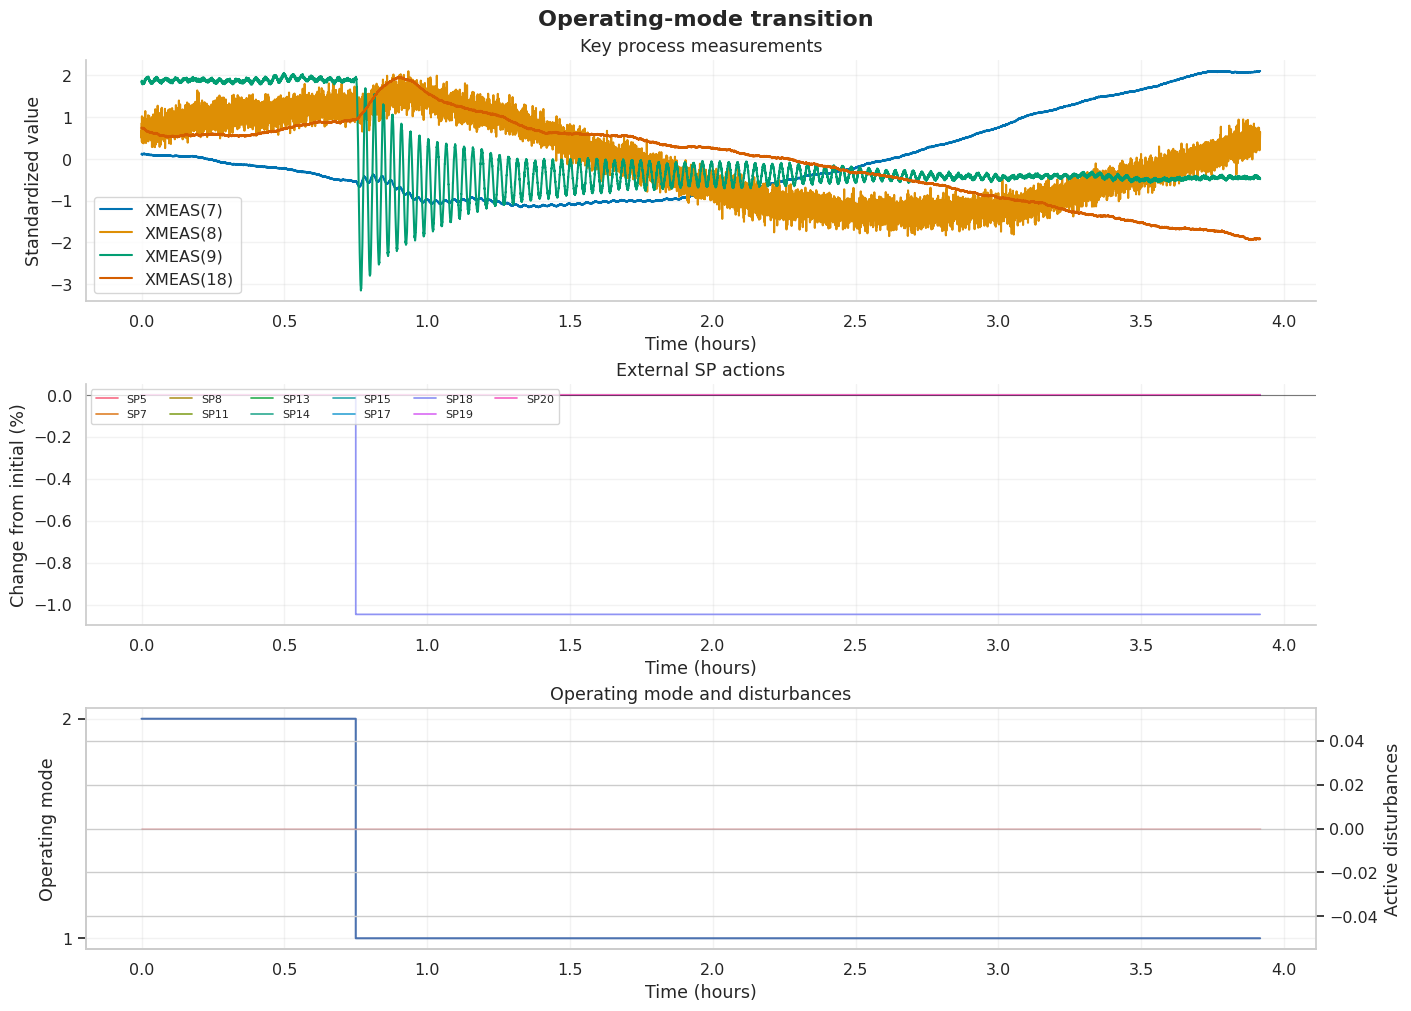

In [14]:
mode_switch_config = example_configs["mode_switch"]
mode_switch_trajectory = TEPDataGenerator(mode_switch_config, initialize=False).generate_trajectory()
show_trajectory(mode_switch_trajectory, mode_switch_config, "Operating-mode transition")


## 批量训练数据生成

下方按配置生成1400条基础轨迹及60对反事实轨迹，保存至固定的 `datasets/tep_latest`。按轨迹组划分训练、验证、测试，反事实对不跨集合。

`data.model_step_minutes=5`；仿真与原始记录仍为1秒。动作保持间隔由 `short_hold_steps=[1,3]`、`long_hold_steps=[6,18]` 和短间隔概率配置，默认对应5–15分钟及30–90分钟。改变模型步后，重新生成数据并训练。

审计同时展示各类轨迹的实际动作次数、动作间隔、同时变化多个SP的事件数和实测越界数量。停车前数据保留用于训练；预测及规划按实际窗口筛选，不用尚未执行的计划事件充数。

In [15]:
from data.data_validation import audit_dataset

# 不传数量参数，按config.yaml执行正式全量生成并显示总体进度。
data_config = load_data_config(project_root / "configs/config.yaml")
full_output_dir = (
    project_root / data_config["output_dir"]
    / data_config["generation"]["dataset_name"]
)
full_result = generate_dataset(
    data_config,
    output_dir=full_output_dir,
    show_progress=True,
)

# 只展示一次数据集级质量审计，不逐条打印轨迹质量门。
dataset_audit = audit_dataset(full_output_dir)
display(pd.DataFrame([full_result["summary"]]))
print(f"数据目录：{full_result['output_dir']}")
print(f"审计通过：{dataset_audit['accepted']}")
print(f"各划分缺失动作：{dataset_audit['missing_actions_by_split']}")
print(f"反事实配对错误：{dataset_audit['counterfactual_pair_errors']}")
print(f"清单指纹一致：{dataset_audit['fingerprint_matches']}")
records_frame = pd.DataFrame(full_result["records"])
records_frame["mean_interval_minutes"] = records_frame["actual_action_event_steps"].map(
    lambda steps: float(np.mean(np.diff(steps)) / 60) if len(steps) > 1 else np.nan
)
display(records_frame.groupby(["split", "scenario_type"]).agg(
    trajectories=("trajectory_id", "count"),
    actual_events=("action_event_count", "mean"),
    multi_sp_events=("multi_sp_event_count", "mean"),
    mean_interval_minutes=("mean_interval_minutes", "mean"),
    complete_pattern_rate=("action_pattern_complete", "mean"),
    observed_unsafe_rate=("observed_unsafe", "mean"),
))


Generating TEP trajectories:   0%|          | 0/1520 [00:00<?, ?trajectory/s]

,trajectory_count,total_transitions,total_duration_hours,scenario_counts,outcome_counts,action_pattern_incomplete_count,boundary_attempt_count,boundary_observed_unsafe_count,mean_action_event_count,mean_action_interval_minutes,split_counts,mode_counts,action_counts,missing_action_sp_numbers,action_coverage_ratio,idv_counts,model_step_seconds,manifest_sha256,config_sha256
0,1520,22724526,6312.368333,"{'single_action': 490, 'disturbance': 168, 'mu...","{'normal': 744, 'near_boundary': 158, 'shutdow...",33,140,140,6.616447,20.399473,"{'train': 1077, 'test': 228, 'validation': 215}","{'1': 398, '4': 369, '2': 368, '5': 385}","{'5': 740, '7': 719, '8': 703, '11': 719, '13'...",[],1.0,"{'20': 6, '3': 21, '5': 13, '6': 13, '12': 13,...",300,ed2bd754974265c78cace8debc75a0ff202dfb36169adb...,d3687a9540ecf88ca1bd51200d5e886b2febc7dbb892b6...


数据目录：/home/lsx/workspace/TWM/datasets/tep_latest
审计通过：True
各划分缺失动作：{'test': [], 'train': [], 'validation': []}
反事实配对错误：[]
清单指纹一致：True


trajectories  actual_events  \
split      scenario_type                                              
test       boundary_action                        19       2.000000   
           counterfactual_intervention            13       8.846154   
           counterfactual_reference               13       0.000000   
           disturbance                            29      10.000000   
           fixed_sp                               12       0.000000   
           mode_switch                            19       0.947368   
           multi_action                           42      10.904762   
           single_action                          81       7.358025   
train      boundary_action                       102       1.950980   
           counterfactual_intervention            38       7.763158   
           counterfactual_reference               38       0.000000   
           disturbance                           108      10.638889   
           fixed_sp                               80       0.000000   
           mode_switch                           106       0.990566   
           multi_action                          259      10.918919   
           single_action                         346       7.413295   
validation boundary_action                        19       2.000000   
           counterfactual_intervention             9       6.666667   
           counterfactual_reference                9       0.000000   
           disturbance                            31      10.354839   
           fixed_sp                               20       0.000000   
           mode_switch                            15       1.000000   
           multi_action                           49      10.551020   
           single_action                          63       7.142857   

                                        multi_sp_events  \
split      scenario_type                                  
test       boundary_action                     1.736842   
           counterfactual_intervention         0.000000   
           counterfactual_reference            0.000000   
           disturbance                         4.448276   
           fixed_sp                            0.000000   
           mode_switch                         0.000000   
           multi_action                        7.666667   
           single_action                       0.000000   
train      boundary_action                     1.843137   
           counterfactual_intervention         0.000000   
           counterfactual_reference            0.000000   
           disturbance                         3.240741   
           fixed_sp                            0.000000   
           mode_switch                         0.000000   
           multi_action                        7.683398   
           single_action                       0.000000   
validation boundary_action                     1.842105   
           counterfactual_intervention         0.000000   
           counterfactual_reference            0.000000   
           disturbance                         3.612903   
           fixed_sp                            0.000000   
           mode_switch                         0.000000   
           multi_action                        7.285714   
           single_action                       0.000000   

                                        mean_interval_minutes  \
split      scenario_type                                        
test       boundary_action                          10.263158   
           counterfactual_intervention              21.124389   
           counterfactual_reference                       NaN   
           disturbance                              20.598246   
           fixed_sp                                       NaN   
           mode_switch                                    NaN   
           multi_action                             22.608410   
           single_action                            21.789662   
train   

## TEP-LeWM 世界模型

第一版模型复用 LeWorldModel（LeWM）的端到端联合嵌入预测思想，并针对TEP的低维连续过程数据进行适配。模型不直接处理图像，而是在潜在空间学习“当前过程状态 + SP动作 → 下一过程状态”的动力学。

| 模块 | TEP适配 | 作用 |
|---|---|---|
| 状态输入 | `XMEAS(41) + XMV(12)`，共53维 | 描述可观测过程状态 |
| 动作输入 | 11个可独立设置的SP | 描述外部控制动作 |
| 状态编码器 | MLP | 将53维状态映射为128维潜在表示 |
| 动作编码器 | LeWM Embedder | 将SP动作映射为条件表示 |
| 动力学预测器 | 动作条件因果Transformer | 根据状态—动作历史预测下一潜在状态 |
| 防坍塌约束 | SIGReg | 约束潜在表示接近各向同性高斯分布 |

1. **轨迹长度**：仿真器每秒记录一次。当前固定SP轨迹为60–180分钟，单动作轨迹为180–300分钟，多动作和干扰轨迹为240–480分钟；提前停车的轨迹以实际长度为准。
2. **轨迹切分**：先按完整轨迹组划分训练、验证和测试集，再在各轨迹内切窗，反事实对不跨集合。采样和滑窗均为一个模型步，默认300秒。每个窗口包含9个观测和8个动作，覆盖40分钟；模型步长为Δ分钟、轨迹长度为D分钟时，样本数为 `max(0, floor(D / Δ) - history_size + 1)`。
3. **时间对齐**：输入为 `observations: (9, 53)` 和 `actions: (8, 11)`；`actions[t]` 在 `observations[t]` 到 `observations[t+1]` 的整个模型步区间内保持不变，默认5分钟。加载轨迹时检查这一条件。所有变量只使用训练集统计量标准化。
4. **训练目标**：每个历史位置预测下一步latent，输出 `(B, 8, 128)`，与真实观测编码得到的下一步latent计算MSE，并加上SIGReg。训练和逐轮验证均只计算单步预测，最佳检查点由验证单步prediction loss选择。
5. **规划推演**：规划时将预测latent反馈给同一个单步predictor，递归执行H步。`planning.horizon`独立于`history_size`和训练窗口长度，可预设或通过验证实验选择；多步推演误差仅用于训练后的评估。

In [16]:
# 建模与训练相关依赖
import os
import subprocess
import torch
import yaml
from torch.utils.data import DataLoader

from data.data_process import TEPWindowDataset, compute_normalization
from data.data_validation import model_step_seconds
from engine.evaluation import (
    evaluate_latent_prediction,
    evaluate_planning_tasks,
    predict_latent_trajectory,
)
from engine.training import train_world_model
from models.model import build_tep_lewm
from utils.evaluation_visualization import (
    plot_latent_prediction_evaluation,
    plot_planning_case,
    plot_latent_trajectory_comparison,
)
from utils.training_visualization import plot_training_history

In [17]:
# 第一步：读取模型配置并实例化TEP-LeWM。
with open(project_root / "configs/config.yaml", encoding="utf-8") as file:
    project_config = yaml.safe_load(file)

model_config = project_config["model"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_tep_lewm(model_config).to(device)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"运行设备：{device}")
print(f"模型参数量：{parameter_count:,}")

运行设备：cuda
模型参数量：1,557,252


### 数据预处理与DataLoader

归一化均值和标准差只从训练集计算，避免验证集信息泄漏。随后按照配置将每条轨迹切分为9个状态和8个动作组成的因果窗口，并分别构造训练与验证DataLoader。窗口内8个相邻转移均接受单步监督，不要求额外的多步未来序列。

In [18]:
# 训练始终读取配置中的latest数据集，避免时间戳目录与配置脱节。
training_config = project_config["training"]
dataset_dir = project_root / training_config["dataset_dir"]
sample_stride = model_step_seconds(project_config["data"])

# 只根据训练轨迹计算53维状态和11维动作的标准化参数。
normalization = compute_normalization(
    dataset_dir,
    split=training_config["train_split"],
    sample_stride_steps=sample_stride,
)

dataset_options = {
    "stats": normalization,
    "history_size": model_config["history_size"],
    "sample_stride_steps": sample_stride,
    "preload": training_config["preload"],
}
train_dataset = TEPWindowDataset(
    dataset_dir, training_config["train_split"], **dataset_options
)
validation_dataset = TEPWindowDataset(
    dataset_dir, training_config["validation_split"], **dataset_options
)

loader_options = {
    "batch_size": training_config["batch_size"],
    "num_workers": training_config["loader_workers"],
    "pin_memory": device.type == "cuda",
}
train_loader = DataLoader(
    train_dataset, shuffle=True, drop_last=True, **loader_options
)
validation_loader = DataLoader(
    validation_dataset, shuffle=False, drop_last=False, **loader_options
)

# 检查数据集规模以及一个真实训练批次的输入维度。
dataset_summary = pd.DataFrame(
    [train_dataset.describe(), validation_dataset.describe()],
    index=["train", "validation"],
)
display(dataset_summary)
first_batch = next(iter(train_loader))
print(f"数据目录：{dataset_dir}")
print(f"模型步长：{sample_stride / 60:g}分钟；训练窗口：{model_config['history_size'] * sample_stride / 60:g}分钟")
print(f"状态批次：{tuple(first_batch['observations'].shape)}")
print(f"动作批次：{tuple(first_batch['actions'].shape)}")
print(f"单步目标观测：{tuple(first_batch['observations'][:, 1:].shape)}")

,trajectory_count,window_count,history_size,sample_stride_seconds
train,1077,46027,8,300
validation,215,9154,8,300


数据目录：/home/lsx/workspace/TWM/datasets/tep_latest
模型步长：5分钟；训练窗口：40分钟
状态批次：(256, 9, 53)
动作批次：(256, 8, 11)
单步目标观测：(256, 8, 53)


### 模型训练

训练接口同时支持单卡和DistributedDataParallel（DDP）多卡训练。每张GPU读取不同的数据分片，损失在所有进程间汇总，仅主进程显示进度和保存检查点。

训练目标为单步latent prediction MSE + `sigreg_weight` × SIGReg，逐轮验证采用相同单步目标，并以验证单步prediction loss选择最佳检查点；测试集不参与模型选择。`batch_size`是单卡批量大小，有效全局批量大小等于它乘以GPU数和梯度累积步数。可在启动Jupyter前用环境变量 `TWM_GPUS=4,5,6,7` 指定本次训练使用的GPU。重构后需重新运行训练，再执行以下评估。

In [19]:
# 多卡通过torchrun启动同一训练接口；TWM_GPUS可限制所用GPU。
selected_gpus = os.environ.get("TWM_GPUS", "").strip()
training_env = os.environ.copy()
if selected_gpus:
    gpu_ids = [item.strip() for item in selected_gpus.split(",") if item.strip()]
    training_env["CUDA_VISIBLE_DEVICES"] = ",".join(gpu_ids)
    gpu_count = len(gpu_ids)
else:
    gpu_count = torch.cuda.device_count()

print(f"本次训练GPU数量：{gpu_count}")
if gpu_count > 1:
    command = [
        sys.executable, "-m", "torch.distributed.run", "--standalone",
        f"--nproc_per_node={gpu_count}",
        str(project_root / "scripts/train.py"),
        "--config", str(project_root / "configs/config.yaml"),
        "--dataset-dir", str(dataset_dir),
        "--device", "cuda",
    ]
    effective_batch = (gpu_count * training_config['batch_size'] *
                       training_config.get('gradient_accumulation_steps', 1))
    print(f"启动DDP训练，有效全局批量大小：{effective_batch}")
    subprocess.run(command, cwd=project_root, env=training_env, check=True)
    training_result = None
else:
    training_result = train_world_model(
        project_config,
        dataset_dir=dataset_dir,
        device="cuda" if gpu_count == 1 else "cpu",
    )
    print(f"最佳检查点：{training_result['best_checkpoint']}")

本次训练GPU数量：8
启动DDP训练，有效全局批量大小：2048



*****************************************
Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
*****************************************
/home/lsx/.local/lib/python3.10/site-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


devices: 8 x cuda:0
global batch size: 2048
train dataset: {'trajectory_count': 1077, 'window_count': 46027, 'history_size': 8, 'sample_stride_seconds': 300}
validation dataset: {'trajectory_count': 215, 'window_count': 9154, 'history_size': 8, 'sample_stride_seconds': 300}
best checkpoint: checkpoints/tep_lewm/best.pt


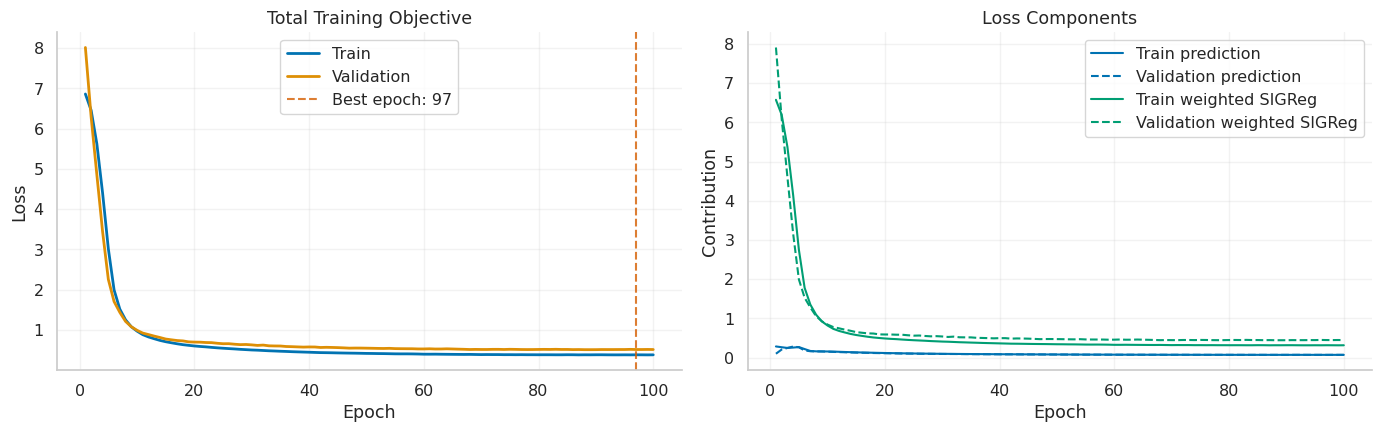

,best_epoch,checkpoint_metric,best_checkpoint_metric,best_validation_loss,best_validation_prediction_loss
0,97,validation_prediction_loss,0.069162,0.516411,0.069162


In [20]:
# 自动读取训练历史、绘制损失并返回最佳模型信息。
training_summary, _, _ = plot_training_history(
    training_config["output_dir"],
    sigreg_weight=training_config["sigreg_weight"],
    search_roots=[project_root, project_root / "tutorial"],
)
plt.show()
display(pd.DataFrame([training_summary]))

## 状态预测评估

在单动作、多动作轨迹中筛选最长预测窗口：窗口内至少两次实际SP变化，多动作窗口至少一次同时改变多个SP。1、2、3、6步误差在同一批最长窗口上计算，因此不要求1步窗口包含两次事件。

给定真实未来动作，递归调用单步predictor，并与真实仿真观测的编码比较latent MSE。默认时长为5、10、15、30分钟；模型没有观测解码器，此处不报告物理量预测误差。评估集合由 `evaluation.split` 选择。

Latent rollout evaluation:   0%|          | 0/7 [00:00<?, ?batch/s]

数据划分：validation
检查点epoch：97
评估窗口数：1,581


,scenario_type,horizon,latent_mse_mean,latent_mse_median,latent_mse_std,window_count,horizon_minutes
0,overall,1,0.079815,0.066149,0.056245,1581,5.0
1,overall,2,0.107959,0.089304,0.074539,1581,10.0
2,overall,3,0.130837,0.106921,0.088310,1581,15.0
3,overall,6,0.191754,0.160181,0.125976,1581,30.0
4,multi_action,1,0.086542,0.070971,0.060702,804,5.0
5,multi_action,2,0.120547,0.099131,0.081188,804,10.0
6,multi_action,3,0.147840,0.119352,0.094997,804,15.0
7,multi_action,6,0.218620,0.189392,0.130318,804,30.0
8,single_action,1,0.072855,0.060361,0.050328,777,5.0
9,single_action,2,0.094933,0.079766,0.064481,777,10.0


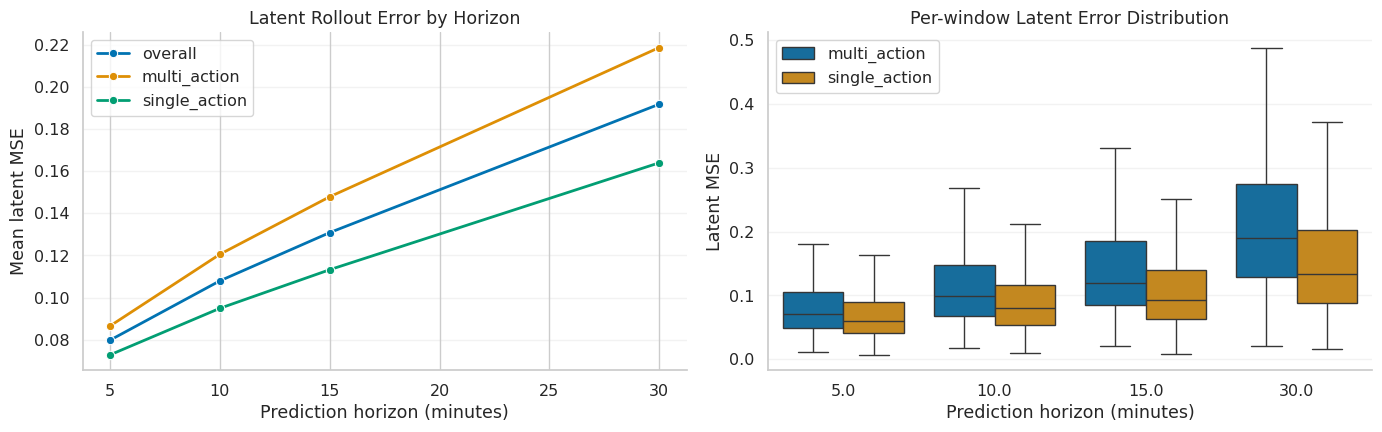

In [21]:
# 定位最佳检查点，并在验证集进行latent推演评估。
checkpoint_relative = Path(training_config["output_dir"]) / "best.pt"
checkpoint_path = next(path for path in [
    checkpoint_relative,
    project_root / checkpoint_relative,
    project_root / "tutorial" / checkpoint_relative,
] if path.is_file())

evaluation_config = project_config["evaluation"]
latent_evaluation = evaluate_latent_prediction(
    checkpoint_path,
    dataset_dir,
    split=evaluation_config["split"],
    scenario_types=evaluation_config["scenario_types"],
    horizons=evaluation_config["horizons"],
    batch_size=evaluation_config["batch_size"],
    device=str(device),
)

print(f"数据划分：{evaluation_config['split']}")
print(f"检查点epoch：{latent_evaluation['checkpoint_epoch']}")
print(f"评估窗口数：{latent_evaluation['window_count']:,}")
display(latent_evaluation["summary"].round(6))
plot_latent_prediction_evaluation(latent_evaluation)
plt.show()

轨迹：traj_000008
最终latent MSE：0.173901


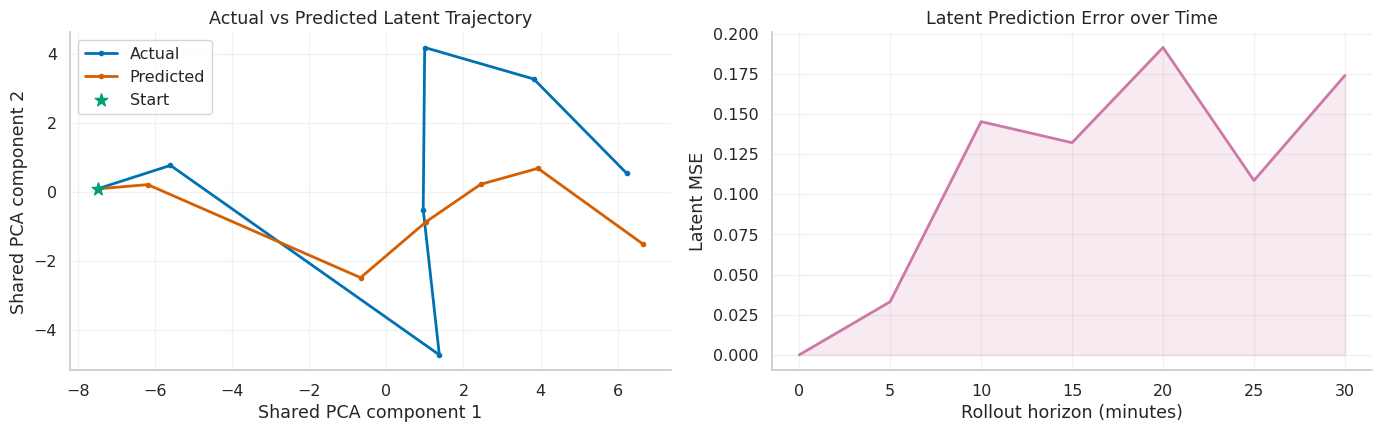

In [22]:
# 展示动作事件附近一条验证轨迹的真实与预测latent差异。
latent_trajectory = predict_latent_trajectory(
    checkpoint_path,
    dataset_dir,
    split=evaluation_config["split"],
    scenario_type="multi_action",
    horizon=max(evaluation_config["horizons"]),
    device=str(device),
)

print(f"轨迹：{latent_trajectory['trajectory_id']}")
print(f"最终latent MSE：{latent_trajectory['latent_mse'][-1]:.6f}")
plot_latent_trajectory_comparison(latent_trajectory)
plt.show()

## 动作规划评估

从单动作、多动作轨迹抽取至少含两次实际动作的任务，多动作任务还须含同时改变多个SP的事件。用 `goal_offset_steps` 步后的实际状态作为固定截止时刻目标，默认6步、30分钟。

参考动作和CEM共用 `generation.action` 中的SP范围、每次变化SP数上限及相邻动作最大阶跃。CEM每个模型步可调节，变化代价覆盖当前→首动作和所有后续相邻动作。MPC默认执行1步后重新规划；单次递归长度为 `min(horizon, 剩余任务步数)`。

筛选包括仿真器状态重放、参考动作可达性、参考路径软边界检查及无动作非平凡性检查。成功要求在截止时刻达到误差阈值，且全程未停车、未越实验软边界。报告终点误差、成功率、停车率、软边界越限率和实际动作次数，并展示参考及无动作基线。软边界监测使用每秒观测。

通过验证集选择H；任务总步数保持固定，避免改变H时同时改变目标。评估集合由 `planning.split` 选择。

In [23]:
# H读取planning.horizon；仅在验证集调节，训练窗口与损失不随H变化。
# 调参完成后再单独运行一次测试集。
planning_split = project_config["planning"]["split"]
step_minutes = model_step_seconds(project_config["data"]) / 60
print(f"规划时域：{project_config['planning']['horizon']}步 = {project_config['planning']['horizon'] * step_minutes:g}分钟")
print(f"目标偏移：{project_config['planning']['goal_offset_steps'] * step_minutes:g}分钟")
planning_evaluation = evaluate_planning_tasks(
    checkpoint_path,
    dataset_dir,
    project_config,
    split=planning_split,
    device=str(device),
)

print(f"数据划分：{planning_evaluation['split']}")
print(f"并行设备：{planning_evaluation['devices']}")
print(f"任务筛选：{planning_evaluation['screening']}")
print("规划评估汇总：")
display(planning_evaluation["summary"].round(4))
print("逐任务结果：")
display(planning_evaluation["per_task"].round(4))

规划时域：6步 = 30分钟
目标偏移：30分钟


CEM-MPC planning evaluation:   0%|          | 0/725 [00:00<?, ?task/s]

数据划分：validation
并行设备：['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3', 'cuda:4', 'cuda:5', 'cuda:6', 'cuda:7']
任务筛选：{'candidate_count': 967, 'evaluated_candidate_count': 208, 'accepted_count': 80, 'rejections': {'insufficient_context': 0, 'disallowed_outcome': 242, 'insufficient_action_changes': 69, 'trivial_goal': 42, 'unsafe_goal': 9, 'unsafe_reference': 8}}
规划评估汇总：


,scenario_type,task_count,trajectory_count,success_rate,shutdown_rate,soft_limit_violation_rate,no_action_success_rate,no_action_shutdown_rate,no_action_soft_limit_violation_rate,reference_action_event_count,planned_action_event_count,initial_xmeas_mse,final_xmeas_mse,oracle_xmeas_mse,no_action_xmeas_mse,mean_improvement,success_mse_threshold
0,overall,80,18,0.0625,0.0,0.1125,0.0,0.0,0.0,3.0750,6.0,0.5083,0.3344,0.0,0.2483,0.1981,0.1
1,multi_action,52,9,0.0385,0.0,0.1538,0.0,0.0,0.0,3.1154,6.0,0.5186,0.3444,0.0,0.2695,0.1585,0.1
2,single_action,28,9,0.1071,0.0,0.0357,0.0,0.0,0.0,3.0000,6.0,0.4890,0.3159,0.0,0.2088,0.2716,0.1


逐任务结果：


,trajectory_id,task_id,split,mode,start_step,replay_xmeas_mse,oracle_xmeas_mse,no_action_xmeas_mse,no_action_alive,no_action_soft_limit_violated,...,soft_limit_violated,control_steps,planning_horizon,elapsed_minutes,scenario_type,initial_xmeas_mse,final_xmeas_mse,improvement,success,alive
0,traj_001137,traj_001137:8100,validation,5,8100,0.0,0.0,0.1322,True,False,...,False,6,6,30.0,single_action,0.4151,0.1011,0.7564,False,True
1,traj_001137,traj_001137:8400,validation,5,8400,0.0,0.0,0.1003,True,False,...,False,6,6,30.0,single_action,0.4442,0.2608,0.4129,False,True
2,traj_000885,traj_000885:7800,validation,1,7800,0.0,0.0,0.1945,True,False,...,False,6,6,30.0,single_action,0.2836,0.0594,0.7904,True,True
3,traj_000885,traj_000885:6000,validation,1,6000,0.0,0.0,0.1722,True,False,...,False,6,6,30.0,single_action,0.4620,0.1104,0.7611,False,True
4,traj_000885,traj_000885:6600,validation,1,6600,0.0,0.0,0.1264,True,False,...,False,6,6,30.0,single_action,0.3823,0.0914,0.7609,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,traj_000394,traj_000394:5400,validation,1,5400,0.0,0.0,0.2257,True,False,...,False,6,6,30.0,single_action,1.0532,1.0565,-0.0031,False,True
76,traj_000394,traj_000394:5100,validation,1,5100,0.0,0.0,0.3458,True,False,...,False,6,6,30.0,single_action,0.9088,1.2603,-0.3868,False,True
77,traj_000394,traj_000394:3900,validation,1,3900,0.0,0.0,0.1289,True,False,...,True,6,6,30.0,single_action,0.6419,0.1440,0.7756,False,True
78,traj_000915,traj_000915:3300,validation,2,3300,0.0,0.0,0.2965,True,False,...,False,6,6,30.0,single_action,0.4859,0.8695,-0.7895,False,True


轨迹：traj_000885 (single_action)
规划成功：True
XMEAS误差改善：79.04%


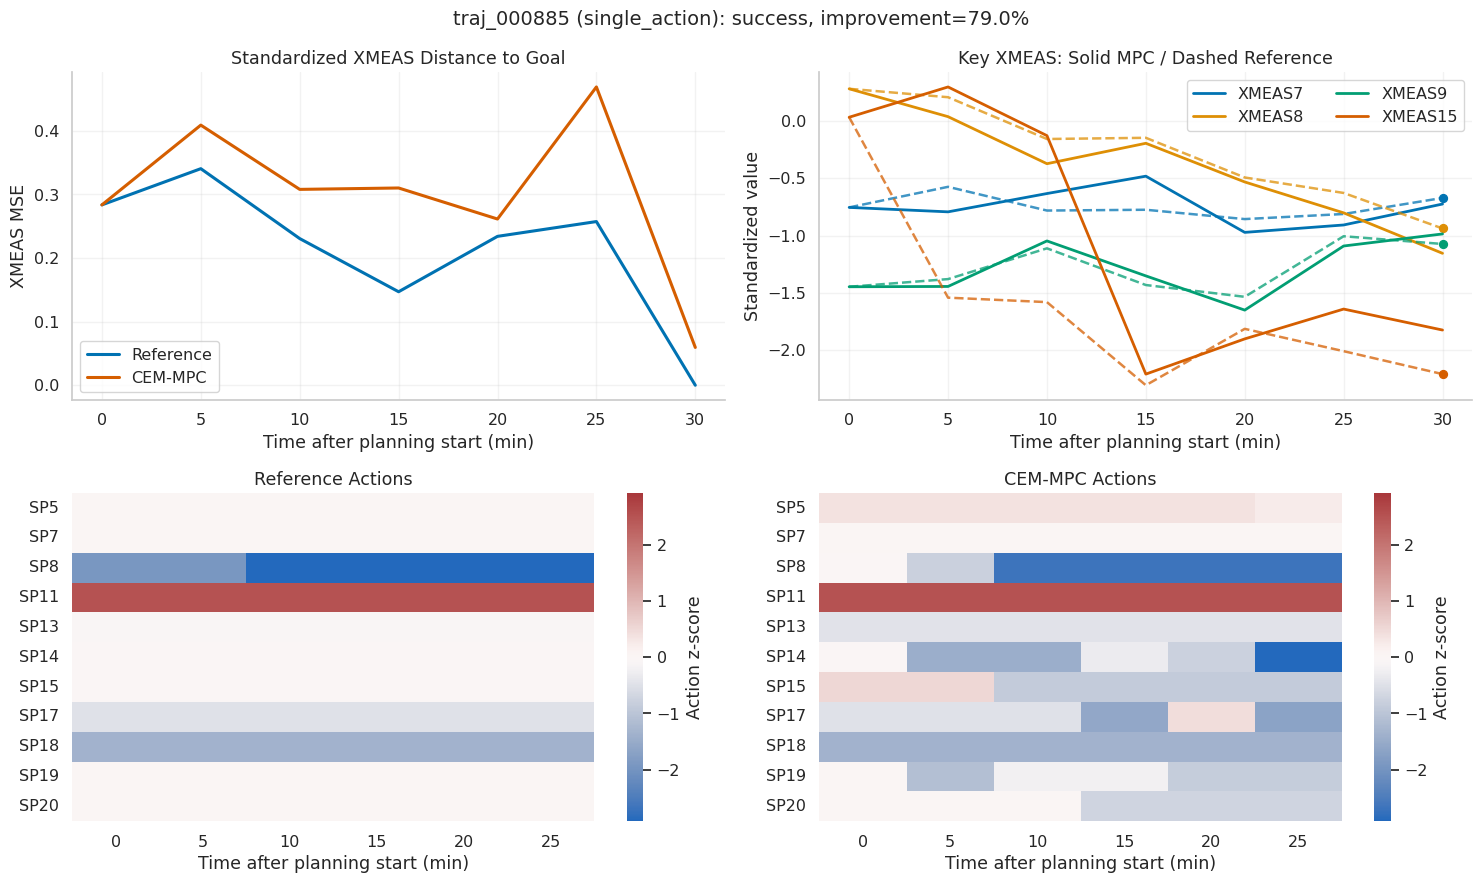

In [24]:
# 优先选择成功任务中改善程度居中的代表性案例；若均失败，则选择最具代表性的失败案例。
planning_case = planning_evaluation["typical_case"]
print(f"轨迹：{planning_case['trajectory_id']} ({planning_case['scenario_type']})")
print(f"规划成功：{planning_case['success']}")
print(f"XMEAS误差改善：{planning_case['improvement']:.2%}")
plot_planning_case(planning_case)
plt.show()

轨迹：traj_000521 (multi_action)
规划存活：True
最终XMEAS MSE：0.2509
XMEAS误差改善：0.15%


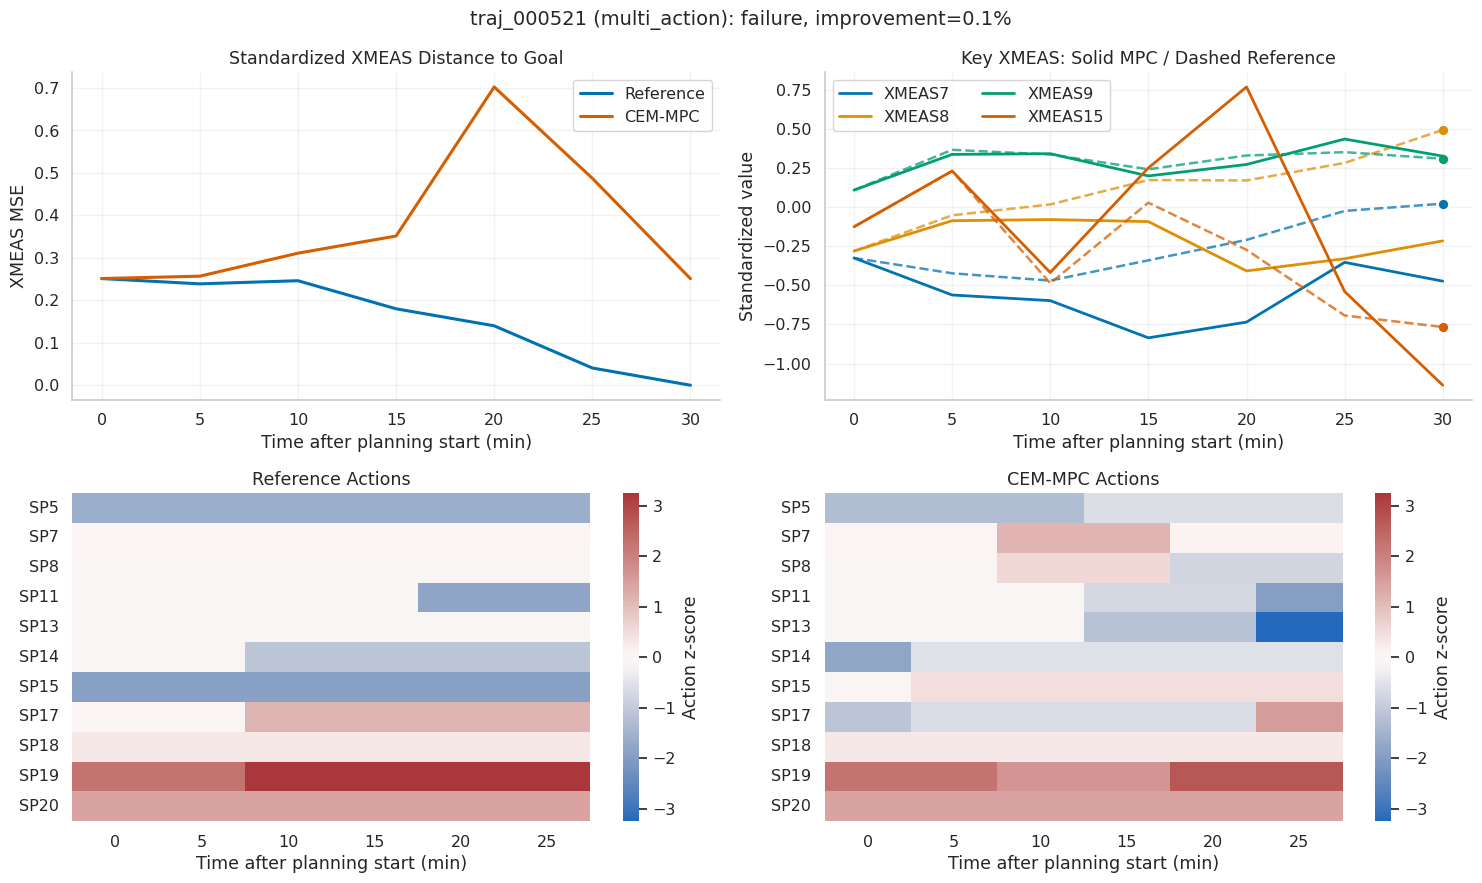

In [25]:
# 选择终点误差接近失败样本中位数的案例，观察典型失败模式。
failed_cases = [case for case in planning_evaluation["cases"] if not case["success"]]
if not failed_cases:
    print("当前评估中没有失败案例。")
else:
    failure_median = np.median([case["final_xmeas_mse"] for case in failed_cases])
    failed_planning_case = min(
        failed_cases, key=lambda case: abs(case["final_xmeas_mse"] - failure_median)
    )
    print(f"轨迹：{failed_planning_case['trajectory_id']} ({failed_planning_case['scenario_type']})")
    print(f"规划存活：{failed_planning_case['alive']}")
    print(f"最终XMEAS MSE：{failed_planning_case['final_xmeas_mse']:.4f}")
    print(f"XMEAS误差改善：{failed_planning_case['improvement']:.2%}")
    plot_planning_case(failed_planning_case)
    plt.show()

### 最终测试

先用validation完成数据策略、模型、H及CEM参数选择。冻结后将配置中的 `evaluation.split` 和 `planning.split` 分别设为对应的 `test_split`，重新读取配置，运行上方预测与规划评估单元一次；无需重新生成数据或训练。